# Aeromagnetic data QC

This notebook demonstrates the use of functions to perform QC of aeromagnetic data.

Here we demonstrate their use on the xxx survey data.

Ensure you have run the `xxx` notebook first so that the xxx data are prepared for review.

___

1. In `checkDiurnal` add check for singleValueExceedance()
1. In `checkDiurnal`, make the code faster - this is much too slow
1. In the Muppet Town example, the DFN file indicates floating point types with a lower case "f" which Inverarity's ASEGGDF code incorrectly interprets as string type. I have changed the DFN file to use upper case, but this is not really acceptable. My preference is to not use ASEGGDF for this task and write my own interpreter.
1. The Muppet Town example is too small with only one flight-line; need a better example data set.
2. The Muppet Town data has constant diurnal so useless for diurnal check.

Hours work done while at AEGC:

    Sat 6 Sep:  3:30
    Sun 7 Sep:  1:30
    Mon 8 Sep:  1:00
    Wed 10 Sep: 1:00
    Thu 11 Sep: 0:00

___

Import the required modules, and set the path to the geowhizz files.

In [1]:
from pathlib import Path
import pegasusQC as qc

In [2]:
dx = Path(r'./MagData/Example_AeroMag_MuppetTown_2009.dat')
dh = dx.with_suffix(".hdf5")

In [9]:
# asegToHdf fails if the file exists so delete it if it does. CHECK
if dx.with_suffix('.hdf5').exists(): 
    dx.with_suffix('.hdf5').unlink()

In [10]:
dh = qc.asegToHDF(Path(dx),
            lineChannel='LINE',
            flightChannel='FLIGHT',
            dateChannel='DATE',
            omitChannels=[], verbose=False)

Key channels for linegroup attributes found:
  LINE at 1, FLIGHT at 2, DATE at 3.

17 channels to be written to geoWhizz file: 
['BGS_JOB', 'LINE', 'FLIGHT', 'DATE', 'FIDUCIAL', 'EAST_MGA', 'NORTH_MGA', 'GDA94LAT', 'GDA94LON', 'MAGUNCMP', 'MAGCOMP', 'DIURNAL', 'IGRF', 'MAG_LEV', 'RAD_ALT', 'GPS_HT', 'DEM']
Writing to geoWhizz file: MagData/Example_AeroMag_MuppetTown_2009.hdf5
L 10010... count = 1050
Setting Line attributes for MagData/Example_AeroMag_MuppetTown_2009.hdf5 to include flight numbers from FLIGHT.
Setting Line attributes for MagData/Example_AeroMag_MuppetTown_2009.hdf5 to include date values from DATE.
NO ACTION TAKEN ON LINE_TYPE - no plan file provided.
NO ACTION TAKEN ON LINE_TYPE - line_type  not in ['Xcal_nsw', 'Xcal_can', 'SGL_GA', 'SGL_NSW', 'NRG', 'ARK', 'SGL_GDF', 'SGL_Kauring'].
Complete.


In [11]:
qc.updateCoordFrame(dh, 
                    lat='GDA94LAT', 
                    lon='GDA94LON', 
                    x='EAST_MGA', 
                    y='NORTH_MGA', 
                    time='FIDUCIAL', 
                    alt='GPS_HT', 
                    geoDatum='WGS84', 
                    htDatum='WGS84', 
                    projection='UTM', 
                    utmz='15')

Changed CoordFrame attribute(s) for Example_AeroMag_MuppetTown_2009.hdf5.


In [3]:
qc.reportSampling(dh)

Whizz Version 1.0
    ProjectName: Unknown Project

Sample time and distance statistics
  Min   = 1.000 s, 4.0 m
  Max   = 1.000 s, 5.0 m
  Mean  = 1.000 s, 4.1 m
  Stdev = 0 s, 0.2 m


In [29]:
qc.reportChannels(dh, verbose=True)

Whizz Version 1.0

17 channels:

  channel              units          description
--------------------------------------------------
  BGS_JOB                             
  DATE                                
  DEM                  METRES         dtm
  DIURNAL              nT             diurnal_gammas
  EAST_MGA             METRES         Easting
  FIDUCIAL                            fiducial
  FLIGHT                              
  GDA94LAT             degrees        wgs84_lat
  GDA94LON             degrees        wgs84_long
  GPS_HT               METRES         gps_height
  IGRF                 nT             igrf_gammas
  LINE                                
  MAGCOMP              nT             mag_gammas
  MAGUNCMP             nT             raw_mag
  MAG_LEV              nT             mag_level
  NORTH_MGA            METRES         Northing
  RAD_ALT              METRES         rad_alt


___

A standard technical specification is the requirement that the basemag data, collected while each line is sampled, not deviate from a straight-line chord of a certain time span by more than a given number of nanoTesla.

The `checkDiurnal` function checks the data for such deviations in `basemag`, deviations being less than `rangeLimit` over chords whose time span is `nSamples` long (as number of fids or samples).

In [27]:
qc.checkDiurnal(dh, 'DIURNAL', lines=[],
                rangeLimit = 0.001, nSamples = 8, plot_flag=True)

  Checked 1 lines, 0 failed.




___

The standard check for noise in aeromagnetic data is the 4th difference.

The function `checkTCDiff4` checks the total magnetic field fourth difference channel in a whizzFile against the specification that the peak to peak variation over a set number of samples must not exceed some peak value. If no fourth difference channel is supplied, then the raw magnetic data channel may be used, and its 4th difference will be calculated by the function.

For a joint gravity-magnetic survey 4th difference noise is typically higher than for a solely magnetometer survey. In the former case, A typical requirement might set the limit to 0.02 nT over 3000 smples.

The `plot_flag` and `verbose` Boolean parameters control whether the results are plotted, and whether a verbose report is given, as usual.

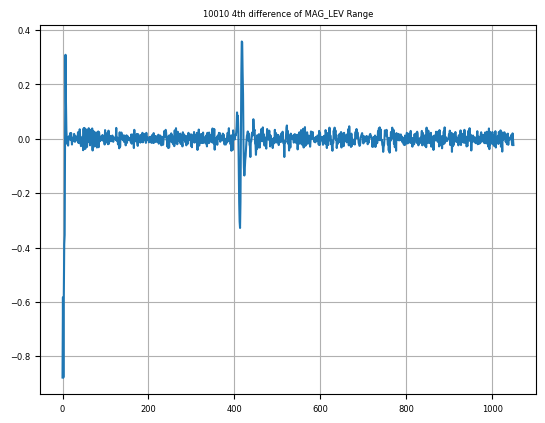

  Checked 1 lines, 1 failed.



In [15]:
qc.checkTCDiff4(dh, TCDiff4='', rawMag='MAG_LEV', lines=[],
                limit=0.1, maxDistance=28, plot_flag=True, verbose=False)

___

It is useful to check the power spectrum of the magnetic data because periodic noise sources can occur and these are often not seen in the standard 4th difference measure. This can be performed at each stage of processing, or just on the raw magnetic data and the final magnetic data. The power spectrum should not have any signs of harmonic signal.

In the example below, there are no spikes in the spectrum above $10^{-3}$ so all okay.

Of 1 lines in database, 1 will be processed.
The first 1050 samples from each line will be used.
Only one flight line in analysis, so results are not reliable.
Line 10010; Num samples = 1050; f_sample = 1.0 Hz; est line length = 66150.0 m. period shape (1575,)


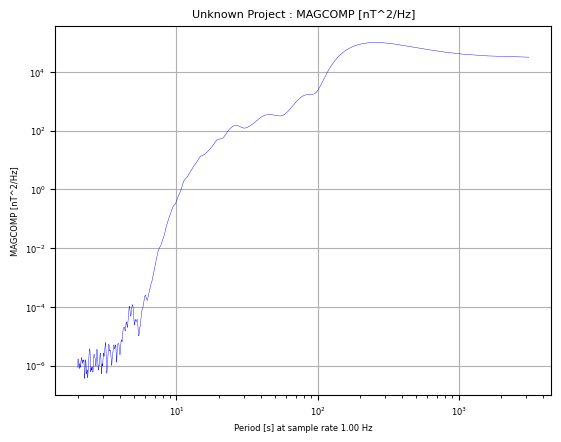

In [3]:
qc.psdChannel(dh, 'MAGCOMP', flightLines=[], shortestPeriod=0.0, minlinelenkm=None, verbose=True)

___

There are other QC checks that should be performed but for which no QC function exists.

Magnetic compensation flights should be:

1. on a magnetically quiet location;
2. at high enough altitude to avoid short wavelength magnetic signal;
3. at a location where local magnetic field variations are less than 100 nT;
4. at a location where the magnetic field gradient is small;
5. with sufficient manoeuvre variation  to give more than 1000 nT signal in each fluxgate magnetometer;
6. over a flight path that forms a complete square;
7. with a fourth difference of the total field less than 0.1 nT over a 1000 m window;
8. delivering a figure-of-merit less than 2 nT.

A magnetometer lag calibration should be performed. Criteria are: ?##?

A magnetomer heading test should be performed. Criteria are: ?##?

___